# Downloading Shards To Colab SSD

In [1]:
# ============================================================
# DOWNLOAD ALL SHARDS FROM test_shards/ (FUTURIST test set)
# ============================================================

import os
from google.colab import auth
from google.cloud import storage
from tqdm import tqdm

BUCKET_NAME = "futurist_project_data"
REMOTE_PREFIX = "test_shards/seq-"       # Correct folder prefix
LOCAL_DIR = "/content/sequence_shards"

print("🔐 Authenticating...")
auth.authenticate_user()

# Setup GCS Client
client = storage.Client(project="explaindrive-ml")
bucket = client.bucket(BUCKET_NAME)

print(f"📁 Local directory: {LOCAL_DIR}")
os.makedirs(LOCAL_DIR, exist_ok=True)

print(f"📦 Listing objects in bucket: {BUCKET_NAME} ...")
all_blobs = list(bucket.list_blobs())

# Filter ONLY test_shards/seq-xxxxx.tar files
shard_blobs = [
    b for b in all_blobs
    if b.name.startswith("test_shards/seq-") and b.name.endswith(".tar")
]

# Sort numerically (seq-00000.tar, seq-00001.tar, ...)
shard_blobs = sorted(shard_blobs, key=lambda x: x.name)

print(f"🎯 Found {len(shard_blobs)} shard files in test_shards/")
for b in shard_blobs[:5]:
    print("   🔹", b.name)

print("\n⬇️ Starting download of all shard files...\n")

for blob in tqdm(shard_blobs, desc="Downloading shards"):
    # Save locally with just seq-00000.tar name
    local_path = os.path.join(LOCAL_DIR, os.path.basename(blob.name))
    blob.download_to_filename(local_path)

print("\n🎉 ALL SHARDS DOWNLOADED SUCCESSFULLY!")
print(f"📁 Files saved in: {LOCAL_DIR}")

🔐 Authenticating...
📁 Local directory: /content/sequence_shards
📦 Listing objects in bucket: futurist_project_data ...
🎯 Found 31 shard files in test_shards/
   🔹 test_shards/seq-00000.tar
   🔹 test_shards/seq-00001.tar
   🔹 test_shards/seq-00002.tar
   🔹 test_shards/seq-00003.tar
   🔹 test_shards/seq-00004.tar

⬇️ Starting download of all shard files...




🎉 ALL SHARDS DOWNLOADED SUCCESSFULLY!
📁 Files saved in: /content/sequence_shards


In [2]:
# ============================================================
# 📌 CELL 2 — Decode .npy + Preprocess + Test Loader (FUTURIST)
# ============================================================

import numpy as np
import torch
!pip install webdataset
import webdataset as wds
from torch.utils.data import DataLoader
from einops import rearrange


# ------------------------------------------------------------
# 1. Decode .npy files from WebDataset
# ------------------------------------------------------------
def decode_npy(key, data):
    if key.endswith(".npy"):
        import io
        return np.load(io.BytesIO(data))
    return data


# ------------------------------------------------------------
# 2. Preprocess segmentation/depth npy arrays -> tensors
# ------------------------------------------------------------
def preprocess_segmentation_npy(arr):
    # arr: [H,W] npy
    return torch.from_numpy(arr).long().unsqueeze(0)  # [1,H,W]

def preprocess_depth_npy(arr):
    return torch.from_numpy(arr).long().unsqueeze(0)  # [1,H,W]


# ------------------------------------------------------------
# 3. Correct FUTURIST Test Loader (NO masking)
# ------------------------------------------------------------
def create_test_loader(shards_pattern):
    """
    Returns a DataLoader over all shards, producing batches:
        seg_ctx4:        [1,4,1,H,W]
        depth_ctx4:      [1,4,1,H,W]
        seg_gt:          [1,1,H,W]
        depth_gt:        [1,1,H,W]
    """

    def process(sample):
        seg_frames = []
        dep_frames = []

        # Load all 5 frames
        for i in range(5):
            seg_arr = preprocess_segmentation_npy(sample[f"label{i:02d}.npy"])
            dep_arr = preprocess_depth_npy(sample[f"depth{i:02d}.npy"])
            seg_frames.append(seg_arr)
            dep_frames.append(dep_arr)

        # Stack into tensors
        seg = torch.stack(seg_frames, dim=0)   # [5,1,H,W]
        dep = torch.stack(dep_frames, dim=0)   # [5,1,H,W]

        return {
            "seg_ctx4": seg[:4],     # [4,1,H,W]
            "depth_ctx4": dep[:4],   # [4,1,H,W]
            "seg_gt": seg[4],        # [1,H,W]
            "depth_gt": dep[4],      # [1,H,W]
        }

    ds = (
        wds.WebDataset(shards_pattern)
        .decode(decode_npy)
        .map(process)
        .batched(1)   # Each sample already has correct dims
    )

    return DataLoader(ds, batch_size=None, num_workers=0)


print("✅ Cell 2 ready: decode, preprocess, test-loader functions loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.3 MB/s eta 0:00:00
✅ Cell 2 ready: decode, preprocess, test-loader functions loaded.


In [3]:
# ============================================================
# FIXED FUTURIST MODEL IMPLEMENTATION
# ============================================================

print("🧠 BUILDING FIXED FUTURIST MODEL ARCHITECTURE...")

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
from einops import rearrange, repeat

# ============================================================
# MODEL CONFIGURATION (UPDATED)
# ============================================================

class FUTURISTConfig:
    # Image dimensions (from Cityscapes dataset)
    IMAGE_HEIGHT = 216  # Using your 288x512 resolution
    IMAGE_WIDTH = 384
    PATCH_SIZE = 12     # Fixed: Paper uses P=16

    # Derived values
    PATCHES_H = IMAGE_HEIGHT // PATCH_SIZE  # 18
    PATCHES_W = IMAGE_WIDTH // PATCH_SIZE   # 32
    NUM_PATCHES = PATCHES_H * PATCHES_W     # 576

    # Model dimensions (scaled down for memory optimization)
    HIDDEN_DIM = 192    # Reduced from 256 for memory
    NUM_LAYERS = 4      # Reduced from 6 for memory
    NUM_HEADS = 4
    MLP_RATIO = 4

    # Modality settings (FIXED according to paper)
    NUM_SEG_CLASSES = 19  # Cityscapes has 19 classes
    NUM_DEPTH_BINS = 50   # Paper uses discrete depth values
    PIXEL_EMBED_DIM = 10  # FIXED: Paper uses C_I=10 for pixel embeddings

    # Sequence settings (FIXED according to paper)
    NUM_CONTEXT = 4      # Paper: N_c=4 context frames
    NUM_FUTURE = 1       # Paper: N_p=1 future frame
    SEQ_LENGTH = NUM_CONTEXT + NUM_FUTURE  # 5

    # Training (we'll override masking to 100% on future)
    MASK_RATIO = 1.0   # Not used anymore for future frame, but kept for reference


config = FUTURISTConfig()

# ============================================================
# 1. HIERARCHICAL TOKENIZATION (FIXED)
# ============================================================

class HierarchicalTokenization(nn.Module):
    """VAE-free hierarchical tokenization - FIXED according to paper"""

    def __init__(self, modality_type, config):
        super().__init__()
        self.config = config
        self.modality_type = modality_type

        if modality_type == 'seg':
            num_values = config.NUM_SEG_CLASSES
        else:  # depth
            num_values = config.NUM_DEPTH_BINS

        # Stage 1: Per-pixel embedding (FIXED: paper uses low-dim embeddings)
        self.pixel_embed = nn.Embedding(num_values, config.PIXEL_EMBED_DIM)

        # Stage 2: Patch projection (FIXED: proper dimension calculation)
        patch_dim = config.PATCH_SIZE * config.PATCH_SIZE * config.PIXEL_EMBED_DIM
        # Each modality gets half the hidden dimension for Concat fusion
        self.patch_proj = nn.Linear(patch_dim, config.HIDDEN_DIM // 2)

    def forward(self, x):
        # x: [B, T, H, W] integer class indices
        batch_size, seq_len, H, W = x.shape

        # Stage 1: Per-pixel embedding
        x_embed = self.pixel_embed(x)  # [B, T, H, W, embed_dim]

        # Reshape for patching: [B, T, H, W, embed_dim] -> [B, T, num_patches, patch_size² * embed_dim]
        x_embed = rearrange(
            x_embed,
            'b t (h p1) (w p2) d -> b t (h w) (p1 p2 d)',
            p1=self.config.PATCH_SIZE,
            p2=self.config.PATCH_SIZE,
            h=self.config.PATCHES_H,
            w=self.config.PATCHES_W
        )

        # Stage 2: Patch projection
        tokens = self.patch_proj(x_embed)  # [B, T, num_patches, hidden_dim//2]

        return tokens

# ============================================================
# 2. MULTIMODAL FUSION (FIXED)
# ============================================================

class MultimodalFusion(nn.Module):
    """Early fusion via concatenation - FIXED: paper uses Concat strategy"""

    def __init__(self, config):
        super().__init__()
        self.config = config

    def forward(self, seg_tokens, depth_tokens):
        # Concat along feature dimension: [B, T, N, D/2] + [B, T, N, D/2] -> [B, T, N, D]
        # This matches paper's Concat strategy where d_S = d_D = d/2
        fused_tokens = torch.cat([seg_tokens, depth_tokens], dim=-1)
        return fused_tokens

# ============================================================
# 3. DECOMPOSED ATTENTION (FIXED)
# ============================================================

# ============================================================
# SCMHSA — Semantic Compression Multi-Head Self-Attention
# ============================================================

class SCMHSA(nn.Module):
    """
    SCMHSA = Q_head_compression + shared semantic projection Ws
    This replaces standard MHSA for TEMPORAL attention only.
    """

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.num_heads = config.NUM_HEADS
        self.d = config.HIDDEN_DIM
        self.d_head = self.d // self.num_heads

        # Standard projections
        self.q_proj = nn.Linear(self.d, self.d)
        self.k_proj = nn.Linear(self.d, self.d)
        self.v_proj = nn.Linear(self.d, self.d)

        # SCMHSA shared compression Wx (paper)
        # Q -> Qh -> Sh
        self.Ws_q = nn.Linear(self.d_head, self.d_head)

        # Final projection
        self.out_proj = nn.Linear(self.d, self.d)

        # Pre-LN
        self.norm = nn.LayerNorm(self.d)

    def forward(self, x):
        """
        x: [B, T, N, D]
        - But temporal attention needs [B*N, T, D]
        """
        B, T, N, D = x.shape

        # Pre-LN
        x = self.norm(x)

        # Bring temporal axis forward
        x = x.permute(0, 2, 1, 3).reshape(B * N, T, D)      # [B*N, T, D]

        # Q, K, V normal projection
        Q = self.q_proj(x)                                  # [BN, T, D]
        K = self.k_proj(x)
        V = self.v_proj(x)

        # Reshape to heads
        Q = Q.view(B * N, T, self.num_heads, self.d_head).transpose(1, 2)
        K = K.view(B * N, T, self.num_heads, self.d_head).transpose(1, 2)
        V = V.view(B * N, T, self.num_heads, self.d_head).transpose(1, 2)

        # SCMHSA SEMANTIC COMPRESSION
        # Apply shared Ws across heads
        Qh = self.Ws_q(Q)                   # [BN, heads, T, d_head]
        Kh = K                              # K does NOT get compressed in paper

        # Attention
        attn = (Qh @ Kh.transpose(-1, -2)) * (1.0 / math.sqrt(self.d_head))
        attn = F.softmax(attn, dim=-1)

        out = attn @ V                      # [BN, heads, T, d_head]
        out = out.transpose(1, 2).reshape(B * N, T, D)

        out = self.out_proj(out)            # final linear

        # reshape back → [B, T, N, D]
        out = out.reshape(B, N, T, D).permute(0, 2, 1, 3)

        return out

class DecomposedAttention(nn.Module):
    """Spatio-temporal decomposed attention (correct Pre-LN)"""

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.head_dim = config.HIDDEN_DIM // config.NUM_HEADS

        # QKV and output projections
        self.qkv = nn.Linear(config.HIDDEN_DIM, 3 * config.HIDDEN_DIM)
        self.proj = nn.Linear(config.HIDDEN_DIM, config.HIDDEN_DIM)

        # REQUIRED Pre-LN (must not be removed)
        self.norm = nn.LayerNorm(config.HIDDEN_DIM)

    def forward(self, x, attention_type='spatial'):
        B, T, N, D = x.shape

        # ---------- PRE-LAYER NORM ----------
        x = self.norm(x)

        # ---------- RESHAPE FOR ATTENTION ----------
        if attention_type == 'spatial':
            # [B, T, N, D] → [B*T, N, D]
            x_flat = x.reshape(B * T, N, D)
            seq_len = N
        else:
            # [B, T, N, D] → [B*N, T, D]
            x_flat = x.permute(0, 2, 1, 3).reshape(B * N, T, D)
            seq_len = T

        # ---------- COMPUTE QKV ----------
        qkv = self.qkv(x_flat).reshape(
            x_flat.shape[0], seq_len, 3, self.config.NUM_HEADS, self.head_dim
        )
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # ---------- ATTENTION ----------
        attn = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.head_dim))
        attn = F.softmax(attn, dim=-1)

        # ---------- OUTPUT ----------
        out = (attn @ v).transpose(1, 2).reshape(x_flat.shape[0], seq_len, D)
        out = self.proj(out)

        # ---------- RESHAPE BACK ----------
        if attention_type == 'spatial':
            out = out.reshape(B, T, N, D)
        else:
            out = out.reshape(B, N, T, D).permute(0, 2, 1, 3)

        return out

# ============================================================
# 4. TRANSFORMER BLOCK (FIXED)
# ============================================================

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        # TEMPORAL = SCMHSA
        self.temporal_attention = SCMHSA(config)

        # SPATIAL = Normal MHSA
        self.spatial_attention = DecomposedAttention(config)

        self.norm1 = nn.LayerNorm(config.HIDDEN_DIM)
        self.norm2 = nn.LayerNorm(config.HIDDEN_DIM)
        self.norm3 = nn.LayerNorm(config.HIDDEN_DIM)

        mlp_dim = config.HIDDEN_DIM * config.MLP_RATIO
        self.mlp = nn.Sequential(
            nn.Linear(config.HIDDEN_DIM, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, config.HIDDEN_DIM)
        )

    def forward(self, x):
        # x: [B, T, N, D]

        # Temporal attention (across frames at same spatial position)
        residual = x
        # If SCMHSA: call without attention_type
        if type(self.temporal_attention).__name__ == "SCMHSA":
          x_temp = self.temporal_attention(self.norm1(x))
        else:
          x_temp = self.temporal_attention(self.norm1(x), 'temporal')
        x = residual + x_temp

        # Spatial attention (within same frame)
        residual = x
        x_spatial = self.spatial_attention(self.norm2(x), 'spatial')
        x = residual + x_spatial

        # MLP
        residual = x
        x = self.mlp(self.norm3(x))
        x = residual + x

        return x

# ============================================================
# 5. SPATIO-TEMPORAL TRANSFORMER (FIXED - DIMENSION ISSUE RESOLVED)
# ============================================================

class SpatioTemporalTransformer(nn.Module):
    """Main transformer backbone - FIXED position embeddings"""

    def __init__(self, config):
        super().__init__()
        self.config = config

        # Position embeddings (FIXED: match exact dimensions)
        self.temp_pos_embed = nn.Parameter(
            torch.randn(1, config.SEQ_LENGTH, 1, config.HIDDEN_DIM) * 0.02
        )
        self.spatial_pos_embed = nn.Parameter(
            torch.randn(1, 1, config.NUM_PATCHES, config.HIDDEN_DIM) * 0.02
        )

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(config) for _ in range(config.NUM_LAYERS)
        ])
        self.norm = nn.LayerNorm(config.HIDDEN_DIM)

    def forward(self, x):
        B, T, N, D = x.shape

        # Add position embeddings (FIXED: ensure dimensions match exactly)
        x = x + self.temp_pos_embed[:, :T, :, :]      # Temporal: [1, T, 1, D]
        x = x + self.spatial_pos_embed[:, :, :N, :]   # Spatial: [1, 1, N, D]

        # Transformer blocks
        for block in self.blocks:
            x = block(x)

        return self.norm(x)

# ============================================================
# 6. MULTIMODAL MASKING (UPDATED: FUTURE FRAME 100% MASKED)
# ============================================================

class MultimodalMasking(nn.Module):
    """
    FUTURIST-style masking:
    - Context frames (0..NUM_CONTEXT-1) are NEVER masked
    - Future frames (last NUM_FUTURE) are ALWAYS 100% masked during training
    - No masking during inference
    """

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.mask_token_seg = nn.Parameter(torch.randn(1, 1, 1, config.HIDDEN_DIM // 2))
        self.mask_token_depth = nn.Parameter(torch.randn(1, 1, 1, config.HIDDEN_DIM // 2))

    def forward(self, seg_tokens, depth_tokens):
      """
      seg_tokens, depth_tokens: [B, T, N, D/2]

      TRAINING:
          - Context frames (0..NUM_CONTEXT-1): unchanged
          - Future frame(s) (last NUM_FUTURE): 100% masked for BOTH seg + depth
          - seg_mask / depth_mask: True for ALL tokens in future frame(s)

      INFERENCE:
          - No masking at all
          - seg_mask / depth_mask = None
      """
      B, T, N, D = seg_tokens.shape
      F = self.config.NUM_FUTURE  # 1

      # Split context and future
      context_seg   = seg_tokens[:, :self.config.NUM_CONTEXT]      # [B, 4, N, D/2]
      context_depth = depth_tokens[:, :self.config.NUM_CONTEXT]

      future_seg   = seg_tokens[:, self.config.NUM_CONTEXT:]       # [B, 1, N, D/2]
      future_depth = depth_tokens[:, self.config.NUM_CONTEXT:]

      # INFERENCE: no masking at all
      if not self.training:
          seg_tokens_masked   = torch.cat([context_seg, future_seg], dim=1)
          depth_tokens_masked = torch.cat([context_depth, future_depth], dim=1)
          seg_mask = None
          depth_mask = None
          return seg_tokens_masked, depth_tokens_masked, seg_mask, depth_mask

      # TRAINING: 100% mask the future frame(s) for BOTH modalities
      masked_seg   = future_seg.clone()
      masked_depth = future_depth.clone()

      # Broadcast mask tokens: [1,1,1,D/2] -> [B,F,N,D/2]
      masked_seg[:]   = self.mask_token_seg
      masked_depth[:] = self.mask_token_depth

      # All tokens in future frame(s) are supervised
      seg_mask   = torch.ones(B, F, N, device=seg_tokens.device, dtype=torch.bool)
      depth_mask = torch.ones(B, F, N, device=seg_tokens.device, dtype=torch.bool)

      # Reconstruct full sequence
      seg_tokens_masked   = torch.cat([context_seg, masked_seg], dim=1)      # [B,5,N,D/2]
      depth_tokens_masked = torch.cat([context_depth, masked_depth], dim=1)  # [B,5,N,D/2]

      return seg_tokens_masked, depth_tokens_masked, seg_mask, depth_mask

# ============================================================
# 7. MULTIMODAL DECODER (FIXED - Weight Tying)
# ============================================================

class MultimodalDecoder(nn.Module):
    """Decoder with weight tying - FIXED according to paper"""

    def __init__(self, seg_embedder, depth_embedder, config):
        super().__init__()
        self.config = config
        self.seg_embedder = seg_embedder
        self.depth_embedder = depth_embedder

        # Project back to patch space (FIXED: mirror of embedder)
        patch_dim = config.PATCH_SIZE * config.PATCH_SIZE * config.PIXEL_EMBED_DIM
        self.seg_proj = nn.Linear(config.HIDDEN_DIM, patch_dim)
        self.depth_proj = nn.Linear(config.HIDDEN_DIM, patch_dim)

    def forward(self, x):
        # Extract only future frames for prediction
        future_tokens = x[:, -self.config.NUM_FUTURE:]  # [B, F, N, D]
        B, F, N, D = future_tokens.shape

        # Project back to patch space
        seg_patch = self.seg_proj(future_tokens)   # [B, F, N, P*P*C]
        depth_patch = self.depth_proj(future_tokens)

        # Reshape to pixel-level and use tied weights (FIXED: paper uses weight tying)
        seg_recon = self._decode_modality(seg_patch, self.seg_embedder.pixel_embed.weight)
        depth_recon = self._decode_modality(depth_patch, self.depth_embedder.pixel_embed.weight)

        return seg_recon, depth_recon

    def _decode_modality(self, patches, embedding_weight):
        B, F, N, patch_dim = patches.shape

        # Reshape to image format: [B, F, N, P*P*C] -> [B, F, H, W, C]
        patches = patches.view(
            B, F, N,
            self.config.PATCH_SIZE, self.config.PATCH_SIZE,
            self.config.PIXEL_EMBED_DIM
        )
        patches = rearrange(
            patches,
            'b f (h w) p1 p2 d -> b f (h p1) (w p2) d',
            h=self.config.PATCHES_H,
            w=self.config.PATCHES_W,
            p1=self.config.PATCH_SIZE,
            p2=self.config.PATCH_SIZE
        )

        # Final projection with weight tying
        # embedding_weight: [num_classes, embed_dim], patches: [B, F, H, W, embed_dim]
        logits = torch.einsum('bfhwd,cd->bfhwc', patches, embedding_weight)  # [B, F, H, W, C]
        logits = logits.permute(0, 1, 4, 2, 3)  # [B, F, C, H, W]

        return logits

# ============================================================
# 8. COMPLETE FIXED FUTURIST MODEL
# ============================================================

class FixedFUTURIST(nn.Module):
    """Complete FUTURIST model with all fixes according to paper"""

    def __init__(self, config):
        super().__init__()
        self.config = config

        # 1. Tokenization (VAE-free) - FIXED
        self.seg_embedder = HierarchicalTokenization('seg', config)
        self.depth_embedder = HierarchicalTokenization('depth', config)

        # 2. Multimodal fusion - FIXED: Concat strategy
        self.fusion = MultimodalFusion(config)

        # 3. Masking strategy - FUTURIST-style (future fully masked)
        self.masking = MultimodalMasking(config)

        # 4. Transformer backbone - Spatio-temporal with decomposed attention
        self.transformer = SpatioTemporalTransformer(config)

        # 5. Decoder - Weight tying
        self.decoder = MultimodalDecoder(self.seg_embedder, self.depth_embedder, config)

        print(f"✅ FIXED FUTURIST Model Created:")
        print(f"   - Parameters: {sum(p.numel() for p in self.parameters()):,}")
        print(f"   - Hidden dim: {config.HIDDEN_DIM}")
        print(f"   - Layers: {config.NUM_LAYERS}")
        print(f"   - Sequence: {config.SEQ_LENGTH} frames ({config.NUM_CONTEXT} context + {config.NUM_FUTURE} future)")
        print(f"   - Image: {config.IMAGE_HEIGHT}x{config.IMAGE_WIDTH} -> {config.NUM_PATCHES} patches")
        print(f"   - Pixel embed dim: {config.PIXEL_EMBED_DIM} (paper: 10)")
        print(f"   - Masking: Future frame 100% masked during training")

    def forward(self, seg_seq, depth_seq, apply_masking=True):
      """
      TRAINING:
          seg_seq, depth_seq: [B, 5, H, W]
          - 4 context frames visible
          - 5th future frame fully masked inside MultimodalMasking

      INFERENCE:
          seg_seq, depth_seq: [B, 4, H, W]
          - we auto-create a dummy 5th frame (all zeros)
          - masking is disabled automatically
      """
      B, T, H, W = seg_seq.shape
      device = seg_seq.device

      # ------------------------------------------------------------
      # 1. INFERENCE CASE: If only 4 frames given, append dummy frame
      # ------------------------------------------------------------
      if T == self.config.NUM_CONTEXT:  # T == 4
          masked_seg_frame = torch.zeros((B, 1, H, W), dtype=torch.long, device=device)
          masked_depth_frame = torch.zeros((B, 1, H, W), dtype=torch.long, device=device)

          # Now sequence becomes [B, 5, H, W]
          seg_seq = torch.cat([seg_seq, masked_seg_frame], dim=1)
          depth_seq = torch.cat([depth_seq, masked_depth_frame], dim=1)

          # DO NOT apply training-time masking at inference
          apply_masking = False

      # Safety check
      assert seg_seq.shape[1] == self.config.SEQ_LENGTH, \
          f"Expected {self.config.SEQ_LENGTH} frames, got {seg_seq.shape[1]}"

      # ------------------------------------------------------------
      # 2. Tokenize inputs
      # ------------------------------------------------------------
      seg_tokens = self.seg_embedder(seg_seq)      # [B, 5, N, D/2]
      depth_tokens = self.depth_embedder(depth_seq)

      # ------------------------------------------------------------
      # 3. Apply FUTURIST masking (training only)
      # ------------------------------------------------------------
      seg_mask = depth_mask = None
      if apply_masking and self.training:
          seg_tokens, depth_tokens, seg_mask, depth_mask = self.masking(
              seg_tokens, depth_tokens
          )

      # ------------------------------------------------------------
      # 4. Multimodal fusion
      # ------------------------------------------------------------
      fused_tokens = self.fusion(seg_tokens, depth_tokens)        # [B, 5, N, D]

      # ------------------------------------------------------------
      # 5. Spatio-temporal Transformer encoder
      # ------------------------------------------------------------
      encoded_tokens = self.transformer(fused_tokens)             # [B, 5, N, D]

      # ------------------------------------------------------------
      # 6. Decode prediction ONLY for future frame (1 frame)
      # ------------------------------------------------------------
      seg_pred, depth_pred = self.decoder(encoded_tokens)         # [B, 1, C, H, W]

      return seg_pred, depth_pred, seg_mask, depth_mask

    def predict_future(self, seg_4, depth_4):
        """
        Convenience method for inference:
        seg_4, depth_4: [B, 4, H, W]
        Returns:
            seg_logits:   [B, C_seg, H, W]
            depth_logits: [B, C_depth, H, W]
        """
        self.eval()
        with torch.no_grad():
            seg_pred, depth_pred, _, _ = self.forward(
                seg_4, depth_4, apply_masking=False
            )
        # seg_pred, depth_pred: [B, 1, C, H, W]
        return seg_pred[:, 0], depth_pred[:, 0]

# ============================================================
# 9. LOSS FUNCTION (FIXED - Masked Cross-Entropy)
# ============================================================

class FixedFUTURISTLoss(nn.Module):
    """Masked multimodal loss function"""

    def __init__(self, config):
        super().__init__()
        self.config = config

    def forward(self, seg_pred, depth_pred, seg_target, depth_target,
                seg_mask=None, depth_mask=None):
        """
        seg_pred, depth_pred: [B, F, C, H, W]  (F = NUM_FUTURE = 1)
        seg_target, depth_target: [B, T, H, W] (T = 5)
        seg_mask, depth_mask: [B, F, N] where N = NUM_PATCHES
        """
        batch_size, num_future, C_seg, H, W = seg_pred.shape
        _, _, C_depth, _, _ = depth_pred.shape

        # ---- 1) Extract only future targets ----
        seg_target_future = seg_target[:, -self.config.NUM_FUTURE:]      # [B, F, H, W]
        depth_target_future = depth_target[:, -self.config.NUM_FUTURE:]  # [B, F, H, W]

        # ---- 2) Flatten predictions & targets ----
        # [B, F, C, H, W] -> [B*F*H*W, C]
        seg_pred_flat = seg_pred.permute(0, 1, 3, 4, 2).reshape(
            batch_size * num_future * H * W, C_seg
        )
        seg_target_flat = seg_target_future.reshape(batch_size * num_future * H * W)

        depth_pred_flat = depth_pred.permute(0, 1, 3, 4, 2).reshape(
            batch_size * num_future * H * W, C_depth
        )
        depth_target_flat = depth_target_future.reshape(batch_size * num_future * H * W)

        # ---- 3) Optional masked loss (token-wise) ----
        if seg_mask is not None and depth_mask is not None:
            # seg_mask, depth_mask: [B, F, N]
            # Flatten to [B*F*N]
            seg_mask_flat = seg_mask.reshape(batch_size * num_future * self.config.NUM_PATCHES)
            depth_mask_flat = depth_mask.reshape(batch_size * num_future * self.config.NUM_PATCHES)

            # Each token corresponds to PATCH_SIZE^2 pixels.
            # Expand mask from tokens -> pixels.
            seg_mask_pixels = repeat(
                seg_mask_flat, 'n -> (n p1 p2)',
                p1=self.config.PATCH_SIZE, p2=self.config.PATCH_SIZE
            )
            depth_mask_pixels = repeat(
                depth_mask_flat, 'n -> (n p1 p2)',
                p1=self.config.PATCH_SIZE, p2=self.config.PATCH_SIZE
            )

            # seg_mask_pixels, depth_mask_pixels: [B*F*H*W] boolean
            seg_loss = F.cross_entropy(
                seg_pred_flat[seg_mask_pixels],
                seg_target_flat[seg_mask_pixels]
            )
            depth_loss = F.cross_entropy(
                depth_pred_flat[depth_mask_pixels],
                depth_target_flat[depth_mask_pixels]
            )
        else:
            # Fallback: loss on all pixels of future frame
            seg_loss = F.cross_entropy(seg_pred_flat, seg_target_flat)
            depth_loss = F.cross_entropy(depth_pred_flat, depth_target_flat)

        total_loss = seg_loss + depth_loss
        return total_loss, seg_loss, depth_loss

# ============================================================
# MEMORY OPTIMIZATION SETTINGS
# ============================================================

import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print("🔧 Memory optimization settings applied:")
print("   - Reduced HIDDEN_DIM: 256 → 192")
print("   - Reduced NUM_LAYERS: 6 → 4")
print("   - PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True")
print("   - Ready for gradient accumulation training")

🧠 BUILDING FIXED FUTURIST MODEL ARCHITECTURE...
🔧 Memory optimization settings applied:
   - Reduced HIDDEN_DIM: 256 → 192
   - Reduced NUM_LAYERS: 6 → 4
   - PYTORCH_CUDA_ALLOC_CONF: expandable_segments:True
   - Ready for gradient accumulation training


In [4]:
# ============================================================
# 📌 CELL 3 — Instantiate FIXED FUTURIST + Load Checkpoint
# ============================================================

import torch
import torch.serialization
torch.serialization.add_safe_globals([FUTURISTConfig])

# Choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Using device: {device}")

# ------------------------------------------------------------
# 1. Instantiate model
# ------------------------------------------------------------
model = FixedFUTURIST(config).to(device)
model.eval()

print("🧠 Model instantiated successfully!")
print(f"📊 Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ------------------------------------------------------------
# 2. Load trained checkpoint
# ------------------------------------------------------------
CHECKPOINT_PATH = "/content/futurist_final.pth"  # your file

print(f"📦 Loading checkpoint from: {CHECKPOINT_PATH}")

ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

# TRUE training checkpoint → must load model_state_dict
if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    print("🔗 Found training checkpoint — loading model_state_dict...")
    state_dict = ckpt["model_state_dict"]
else:
    print("🔗 Found pure weights file — loading directly...")
    state_dict = ckpt

missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)

print("⚠️ Missing keys:", missing_keys)
print("⚠️ Unexpected keys:", unexpected_keys)

# ------------------------------------------------------------
# 3. Ready for inference
# ------------------------------------------------------------
model.eval()
torch.set_grad_enabled(False)

print("✅ Model checkpoint loaded successfully and ready for inference!")

🔥 Using device: cuda
✅ FIXED FUTURIST Model Created:
   - Parameters: 3,331,698
   - Hidden dim: 192
   - Layers: 4
   - Sequence: 5 frames (4 context + 1 future)
   - Image: 216x384 -> 576 patches
   - Pixel embed dim: 10 (paper: 10)
   - Masking: Future frame 100% masked during training
🧠 Model instantiated successfully!
📊 Total Parameters: 3,331,698
📦 Loading checkpoint from: /content/futurist_final.pth
🔗 Found training checkpoint — loading model_state_dict...
⚠️ Missing keys: []
⚠️ Unexpected keys: []
✅ Model checkpoint loaded successfully and ready for inference!


In [5]:
# ============================================================
# 📌 CELL 4 — Build Test Loader + Run Inference (FIXED)
# ============================================================

from tqdm import tqdm
import glob

# ------------------------------------------------------------
# 1. Resolve tar shard paths
# ------------------------------------------------------------
shards = sorted(glob.glob("/content/sequence_shards/seq-*.tar"))

print("🔍 Found shards:")
for s in shards[:5]:
    print("   ", s)

if len(shards) == 0:
    raise RuntimeError("❌ No tar files found at /content/sequence_shards/")

# ------------------------------------------------------------
# 2. Build test loader
# ------------------------------------------------------------
test_loader = create_test_loader(shards)
print("✅ Test loader created!")


# ------------------------------------------------------------
# 3. Inference loop
# ------------------------------------------------------------
all_outputs = []

print("\n🚀 Starting inference...\n")

for batch in tqdm(test_loader, desc="Inference"):
    seg_ctx4   = batch["seg_ctx4"].to(device).squeeze(2)
    depth_ctx4 = batch["depth_ctx4"].to(device).squeeze(2)

    seg_gt     = batch["seg_gt"].to(device).squeeze(1)
    depth_gt   = batch["depth_gt"].to(device).squeeze(1)

    seg_logits, depth_logits = model.predict_future(seg_ctx4, depth_ctx4)

    seg_pred   = seg_logits.argmax(dim=1)
    depth_pred = depth_logits.argmax(dim=1)

    all_outputs.append({
        "seg_pred": seg_pred.cpu(),
        "depth_pred": depth_pred.cpu(),
        "seg_gt": seg_gt.cpu(),
        "depth_gt": depth_gt.cpu(),
    })

print("\n🎉 Inference complete!")
print("📝 Samples processed:", len(all_outputs))


/usr/local/lib/python3.12/dist-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


🔍 Found shards:
    /content/sequence_shards/seq-00000.tar
    /content/sequence_shards/seq-00001.tar
    /content/sequence_shards/seq-00002.tar
    /content/sequence_shards/seq-00003.tar
    /content/sequence_shards/seq-00004.tar
✅ Test loader created!

🚀 Starting inference...



Inference: 7576it [01:42, 74.09it/s]


🎉 Inference complete!
📝 Samples processed: 7576


In [6]:
# ============================================================
# 📌 CELL 5 — Visualization for Segmentation + Depth Predictions
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import torch

# ------------------------------------------------------------
# 1. Cityscapes 19-class color palette (RGB)
# ------------------------------------------------------------
CITYSCAPES_COLORS = np.array([
    (128, 64,128),   # 0  road
    (244, 35,232),   # 1  sidewalk
    ( 70, 70, 70),   # 2  building
    (102,102,156),   # 3  wall
    (190,153,153),   # 4  fence
    (153,153,153),   # 5  pole
    (250,170, 30),   # 6  traffic light
    (220,220,  0),   # 7  traffic sign
    (107,142, 35),   # 8  vegetation
    (152,251,152),   # 9  terrain
    ( 70,130,180),   # 10 sky
    (220, 20, 60),   # 11 person
    (255,  0,  0),   # 12 rider
    (  0,  0,142),   # 13 car
    (  0,  0, 70),   # 14 truck
    (  0, 60,100),   # 15 bus
    (  0, 80,100),   # 16 train
    (  0,  0,230),   # 17 motorcycle
    (119, 11, 32),   # 18 bicycle
], dtype=np.uint8)


def colorize_segmentation(seg):
    """
    seg: [H,W] integer classes 0-18
    returns RGB image [H,W,3]
    """
    seg_np = seg.cpu().numpy().astype(np.int32)
    colored = CITYSCAPES_COLORS[seg_np]
    return colored


# ------------------------------------------------------------
# 2. Depth visualization (argmax bins → heatmap)
# ------------------------------------------------------------
def visualize_depth(depth, cmap='viridis'):
    """
    depth: [H,W] integer bins (0-49)
    Returns RGB visualization.
    """
    depth_np = depth.cpu().numpy().astype(np.float32)
    depth_norm = depth_np / depth_np.max() if depth_np.max() > 0 else depth_np

    # apply colormap
    colored = plt.get_cmap(cmap)(depth_norm)
    colored = (colored[:, :, :3] * 255).astype(np.uint8)
    return colored


# ------------------------------------------------------------
# 3. Full visualization of one sample
# ------------------------------------------------------------
def show_prediction(sample_idx, outputs):
    """
    outputs = all_outputs from Cell 4
    sample_idx = index of sample
    """

    item = outputs[sample_idx]

    seg_pred  = item["seg_pred"][0]    # [H,W]
    seg_gt    = item["seg_gt"][0]
    depth_pred = item["depth_pred"][0]
    depth_gt   = item["depth_gt"][0]

    seg_pred_color = colorize_segmentation(seg_pred)
    seg_gt_color   = colorize_segmentation(seg_gt)

    depth_pred_color = visualize_depth(depth_pred)
    depth_gt_color   = visualize_depth(depth_gt)

    # Plot
    fig, ax = plt.subplots(2, 2, figsize=(12, 10))

    ax[0,0].imshow(seg_gt_color)
    ax[0,0].set_title("GT Segmentation")
    ax[0,0].axis("off")

    ax[0,1].imshow(seg_pred_color)
    ax[0,1].set_title("Predicted Segmentation")
    ax[0,1].axis("off")

    ax[1,0].imshow(depth_gt_color)
    ax[1,0].set_title("GT Depth (binned)")
    ax[1,0].axis("off")

    ax[1,1].imshow(depth_pred_color)
    ax[1,1].set_title("Predicted Depth (binned)")
    ax[1,1].axis("off")

    plt.tight_layout()
    plt.show()

print("🎨 Visualization utilities ready! Use show_prediction(i, all_outputs)")

🎨 Visualization utilities ready! Use show_prediction(i, all_outputs)


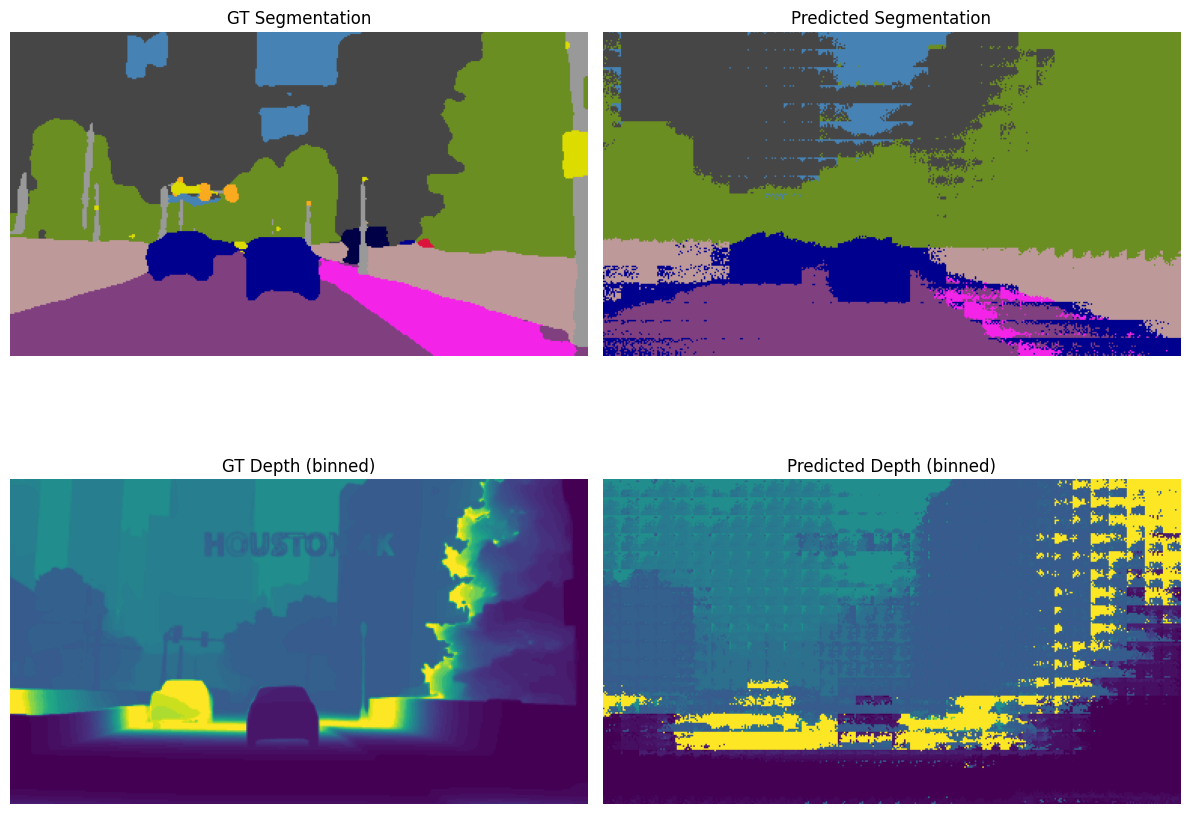

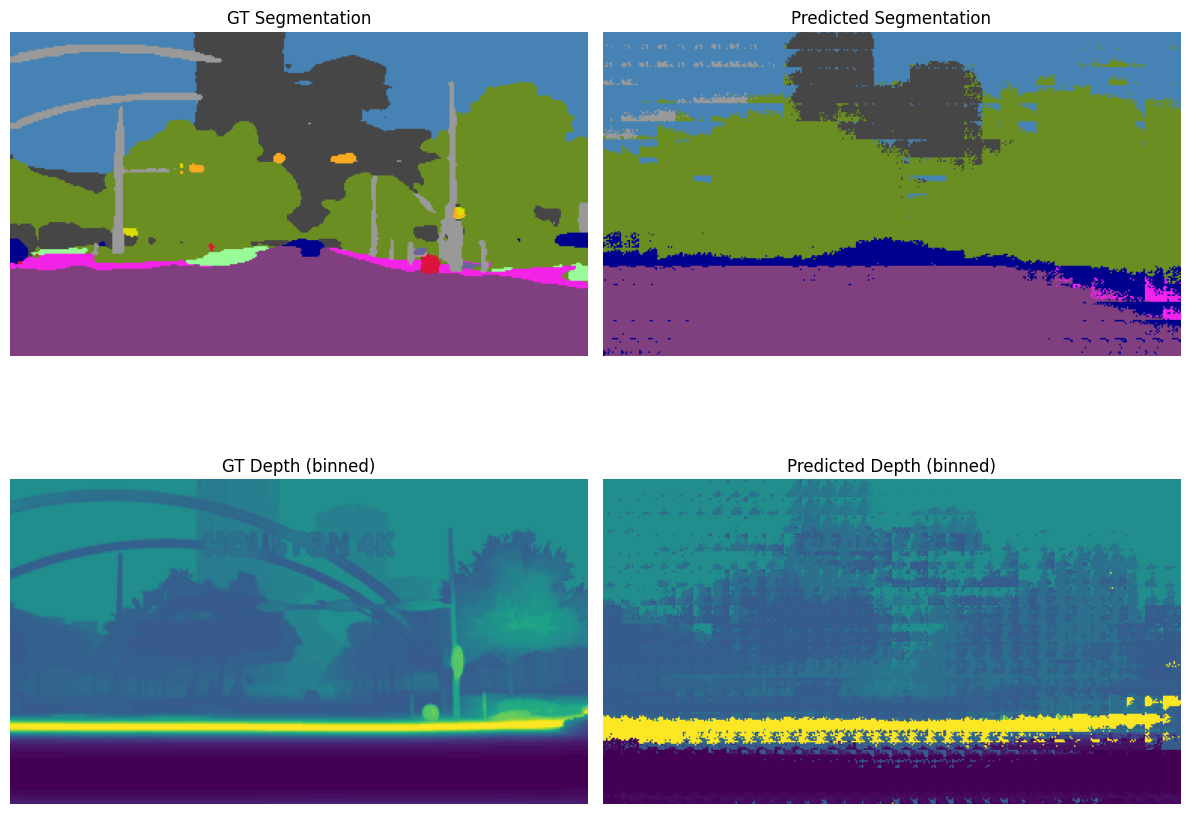

In [7]:
show_prediction(0, all_outputs)    # visualize first result
show_prediction(20, all_outputs)   # visualize sample 10

In [8]:
# ============================================================
# 📌 CELL 6 — Compute Segmentation mIoU on All Predictions
# ============================================================

import numpy as np
import torch

NUM_CLASSES = config.NUM_SEG_CLASSES  # 19


# ------------------------------------------------------------
# 1. Per-class IoU calculation
# ------------------------------------------------------------
def compute_iou(pred, gt, num_classes=19):
    """
    pred: [H,W] int class map
    gt:   [H,W] int class map
    """
    pred = pred.cpu().numpy()
    gt   = gt.cpu().numpy()

    ious = []

    for cls in range(num_classes):
        pred_mask = (pred == cls)
        gt_mask   = (gt == cls)

        intersection = np.logical_and(pred_mask, gt_mask).sum()
        union        = np.logical_or(pred_mask, gt_mask).sum()

        if union == 0:
            # If class doesn't appear in gt, ignore for IoU
            continue
        else:
            ious.append(intersection / union)

    if len(ious) == 0:
        return 0.0

    return np.mean(ious)


# ------------------------------------------------------------
# 2. Compute mIoU over ALL samples in all_outputs
# ------------------------------------------------------------
def evaluate_segmentation_miou(outputs):
    iou_scores = []

    for item in outputs:
        seg_pred = item["seg_pred"][0]   # [H,W]
        seg_gt   = item["seg_gt"][0]     # [H,W]

        iou = compute_iou(seg_pred, seg_gt, NUM_CLASSES)
        iou_scores.append(iou)

    mean_iou = np.mean(iou_scores)

    return mean_iou, iou_scores


# ------------------------------------------------------------
# 3. Run evaluation
# ------------------------------------------------------------
mean_iou, per_sample_ious = evaluate_segmentation_miou(all_outputs)

print("==============================================================")
print(f"🎯 FINAL SEGMENTATION mIoU (future frame only): {mean_iou:.4f}")
print("==============================================================")

🎯 FINAL SEGMENTATION mIoU (future frame only): 0.2481


In [9]:
# ============================================================
# 📌 CELL 7 — Depth Evaluation: AbsRel, RMSE, δ1/δ2/δ3
# ============================================================

import numpy as np
import torch

# --------------------------------------------
# 1. Define the physical depth range
# --------------------------------------------
MIN_DEPTH = 1.0    # meters
MAX_DEPTH = 80.0   # meters
NUM_BINS  = config.NUM_DEPTH_BINS  # 50


# --------------------------------------------
# 2. Convert predicted bin -> continuous depth
# --------------------------------------------
def bins_to_depth(bin_map):
    """
    bin_map: [H,W] ints 0..49
    output: continuous depth [H,W] in meters
    """
    bin_map = bin_map.cpu().numpy().astype(np.float32)
    depth = MIN_DEPTH + (bin_map / (NUM_BINS - 1)) * (MAX_DEPTH - MIN_DEPTH)
    return depth


# --------------------------------------------
# 3. Depth metrics
# --------------------------------------------
def depth_metrics(pred_depth, gt_depth):
    """
    pred_depth, gt_depth: continuous depth [H,W] in meters
    """
    pred = pred_depth.flatten()
    gt   = gt_depth.flatten()

    # avoid zeros
    valid_mask = gt > 0
    pred = pred[valid_mask]
    gt   = gt[valid_mask]

    # AbsRel
    absrel = np.mean(np.abs(pred - gt) / gt)

    # RMSE
    rmse = np.sqrt(np.mean((pred - gt) ** 2))

    # Threshold accuracies
    ratio = np.maximum(pred / gt, gt / pred)
    d1 = (ratio < 1.25).mean()
    d2 = (ratio < 1.25 ** 2).mean()
    d3 = (ratio < 1.25 ** 3).mean()

    return absrel, rmse, d1, d2, d3


# --------------------------------------------
# 4. Evaluate all samples in all_outputs
# --------------------------------------------
def evaluate_depth(outputs):
    absrel_list = []
    rmse_list = []
    d1_list = []
    d2_list = []
    d3_list = []

    for item in outputs:
        # get binned depth predictions + GT
        pred_bin = item["depth_pred"][0]   # [H,W]
        gt_bin   = item["depth_gt"][0]     # [H,W]

        # convert to continuous depth in meters
        pred_depth = bins_to_depth(pred_bin)
        gt_depth   = bins_to_depth(gt_bin)

        # compute metrics
        absrel, rmse, d1, d2, d3 = depth_metrics(pred_depth, gt_depth)

        absrel_list.append(absrel)
        rmse_list.append(rmse)
        d1_list.append(d1)
        d2_list.append(d2)
        d3_list.append(d3)

    return {
        "AbsRel": np.mean(absrel_list),
        "RMSE":   np.mean(rmse_list),
        "δ1":     np.mean(d1_list),
        "δ2":     np.mean(d2_list),
        "δ3":     np.mean(d3_list),
    }


# --------------------------------------------
# 5. Run entire depth evaluation
# --------------------------------------------
depth_results = evaluate_depth(all_outputs)

print("==============================================================")
print("🎯 DEPTH METRICS (future frame only, binned → continuous):")
print(f"   AbsRel: {depth_results['AbsRel']:.4f}")
print(f"   RMSE:   {depth_results['RMSE']:.4f}")
print(f"   δ1:     {depth_results['δ1']:.4f}")
print(f"   δ2:     {depth_results['δ2']:.4f}")
print(f"   δ3:     {depth_results['δ3']:.4f}")
print("==============================================================")


🎯 DEPTH METRICS (future frame only, binned → continuous):
   AbsRel: 0.8930
   RMSE:   15.9760
   δ1:     0.6895
   δ2:     0.7728
   δ3:     0.8273


In [10]:
# ============================================================
# 📌 CELL 8 — Save Predictions (Segmentation + Depth) to Disk
# ============================================================

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Output directories
# ------------------------------------------------------------
OUTPUT_ROOT = "/content/futurist_predictions"

SEG_PRED_DIR = os.path.join(OUTPUT_ROOT, "segmentation_pred")
SEG_GT_DIR   = os.path.join(OUTPUT_ROOT, "segmentation_gt")

DEPTH_PRED_DIR = os.path.join(OUTPUT_ROOT, "depth_pred")
DEPTH_GT_DIR   = os.path.join(OUTPUT_ROOT, "depth_gt")

# Make directories
for d in [SEG_PRED_DIR, SEG_GT_DIR, DEPTH_PRED_DIR, DEPTH_GT_DIR]:
    os.makedirs(d, exist_ok=True)

print("📁 Output folders created at:", OUTPUT_ROOT)


# ------------------------------------------------------------
# 2. Helpers to save PNGs
# ------------------------------------------------------------

def save_png(arr, path):
    """
    arr: [H,W,3] uint8
    """
    Image.fromarray(arr).save(path)


# ------------------------------------------------------------
# 3. Export each sample in all_outputs
# ------------------------------------------------------------

print("\n💾 Saving predictions to disk...\n")

for idx, item in enumerate(all_outputs):

    # ------------ SEGMENTATION ------------
    seg_pred_color = colorize_segmentation(item["seg_pred"][0])   # [H,W,3]
    seg_gt_color   = colorize_segmentation(item["seg_gt"][0])     # [H,W,3]

    save_png(seg_pred_color, f"{SEG_PRED_DIR}/sample_{idx:05d}.png")
    save_png(seg_gt_color,   f"{SEG_GT_DIR}/sample_{idx:05d}.png")

    # Also save raw class indices as .npy
    np.save(f"{SEG_PRED_DIR}/sample_{idx:05d}.npy",
            item["seg_pred"][0].cpu().numpy())
    np.save(f"{SEG_GT_DIR}/sample_{idx:05d}.npy",
            item["seg_gt"][0].cpu().numpy())


    # ------------ DEPTH ------------
    depth_pred_color = visualize_depth(item["depth_pred"][0])  # [H,W,3]
    depth_gt_color   = visualize_depth(item["depth_gt"][0])

    save_png(depth_pred_color, f"{DEPTH_PRED_DIR}/sample_{idx:05d}.png")
    save_png(depth_gt_color,   f"{DEPTH_GT_DIR}/sample_{idx:05d}.png")

    # Save raw depth bins as .npy
    np.save(f"{DEPTH_PRED_DIR}/sample_{idx:05d}.npy",
            item["depth_pred"][0].cpu().numpy())
    np.save(f"{DEPTH_GT_DIR}/sample_{idx:05d}.npy",
            item["depth_gt"][0].cpu().numpy())


print("🎉 All predictions exported successfully!")
print(f"📦 Segmentation predictions → {SEG_PRED_DIR}")
print(f"📦 Segmentation GT → {SEG_GT_DIR}")
print(f"📦 Depth predictions → {DEPTH_PRED_DIR}")
print(f"📦 Depth GT → {DEPTH_GT_DIR}")


📁 Output folders created at: /content/futurist_predictions

💾 Saving predictions to disk...

🎉 All predictions exported successfully!
📦 Segmentation predictions → /content/futurist_predictions/segmentation_pred
📦 Segmentation GT → /content/futurist_predictions/segmentation_gt
📦 Depth predictions → /content/futurist_predictions/depth_pred
📦 Depth GT → /content/futurist_predictions/depth_gt


In [11]:
!zip -r /content/futurist_predictions.zip /content/futurist_predictions

Streaming output truncated to the last 5000 lines.
  adding: content/futurist_predictions/segmentation_pred/sample_07540.png (stored 0%)
  adding: content/futurist_predictions/segmentation_pred/sample_04874.npy (deflated 99%)
  adding: content/futurist_predictions/segmentation_pred/sample_07082.npy (deflated 99%)
  adding: content/futurist_predictions/segmentation_pred/sample_02237.png (stored 0%)
  adding: content/futurist_predictions/segmentation_pred/sample_01927.png (stored 0%)
  adding: content/futurist_predictions/segmentation_pred/sample_00270.npy (deflated 98%)
  adding: content/futurist_predictions/segmentation_pred/sample_04647.npy (deflated 99%)
  adding: content/futurist_predictions/segmentation_pred/sample_03799.png (deflated 1%)
  adding: content/futurist_predictions/segmentation_pred/sample_02008.npy (deflated 99%)
  adding: content/futurist_predictions/segmentation_pred/sample_02075.npy (deflated 99%)
  adding: content/futurist_predictions/segmentation_pred/sample_05847

In [12]:
from google.colab import files
files.download('/content/futurist_predictions.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# ============================================================
# 📌 CELL 9A — Create Videos (Segmentation + Depth)
# ============================================================

import cv2
import numpy as np
import os
from PIL import Image


# ------------------------------------------------------------
# 1. Output directory for videos
# ------------------------------------------------------------
VIDEO_DIR = "/content/futurist_videos"
os.makedirs(VIDEO_DIR, exist_ok=True)

print("📁 Video directory:", VIDEO_DIR)


# ------------------------------------------------------------
# 2. Helper: Write video with OpenCV (expects RGB)
# ------------------------------------------------------------
def write_video(frames, save_path, fps=5):
    """
    frames: list of [H,W,3] uint8 images
    """
    h, w, _ = frames[0].shape
    out = cv2.VideoWriter(
        save_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (w, h)
    )
    for frame in frames:
        # Convert RGB → BGR for OpenCV
        out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    out.release()


# ------------------------------------------------------------
# 3. Build videos for segmentation + depth
# ------------------------------------------------------------
seg_pred_frames = []
seg_gt_frames = []
depth_pred_frames = []
depth_gt_frames = []
compare_seg_frames = []
compare_depth_frames = []

print("🎞 Collecting frames...")

for item in all_outputs:

    # ---- segmentation ----
    seg_pred_color = colorize_segmentation(item["seg_pred"][0])
    seg_gt_color   = colorize_segmentation(item["seg_gt"][0])

    seg_pred_frames.append(seg_pred_color)
    seg_gt_frames.append(seg_gt_color)

    # side-by-side segmentation
    seg_compare = np.concatenate([seg_gt_color, seg_pred_color], axis=1)
    compare_seg_frames.append(seg_compare)

    # ---- depth ----
    depth_pred_color = visualize_depth(item["depth_pred"][0])
    depth_gt_color   = visualize_depth(item["depth_gt"][0])

    depth_pred_frames.append(depth_pred_color)
    depth_gt_frames.append(depth_gt_color)

    # side-by-side depth
    depth_compare = np.concatenate([depth_gt_color, depth_pred_color], axis=1)
    compare_depth_frames.append(depth_compare)


print("🎬 Writing videos...")

# ------------------------------------------------------------
# 4. Write all videos
# ------------------------------------------------------------
write_video(seg_pred_frames,      f"{VIDEO_DIR}/segmentation_pred.mp4")
write_video(seg_gt_frames,        f"{VIDEO_DIR}/segmentation_gt.mp4")
write_video(compare_seg_frames,   f"{VIDEO_DIR}/seg_seg_comparison.mp4")

write_video(depth_pred_frames,    f"{VIDEO_DIR}/depth_pred.mp4")
write_video(depth_gt_frames,      f"{VIDEO_DIR}/depth_gt.mp4")
write_video(compare_depth_frames, f"{VIDEO_DIR}/depth_comparison.mp4")

print("🎉 Videos saved!")
print("📦 segmentation_pred.mp4")
print("📦 segmentation_gt.mp4")
print("📦 seg_seg_comparison.mp4")
print("📦 depth_pred.mp4")
print("📦 depth_gt.mp4")
print("📦 depth_comparison.mp4")


📁 Video directory: /content/futurist_videos
🎞 Collecting frames...
🎬 Writing videos...
🎉 Videos saved!
📦 segmentation_pred.mp4
📦 segmentation_gt.mp4
📦 seg_seg_comparison.mp4
📦 depth_pred.mp4
📦 depth_gt.mp4
📦 depth_comparison.mp4
